In [31]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd
# Machine Learning (zentral)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn import datasets

# (Optional für erweiterte ML-Workflows)
# import optuna           # Hyperparameter-Tuning
# import mlflow           # Experiment-Tracking
# import yellowbrick      # Visualisierung von ML-Modellen

# Lesson 1

In [13]:
diabetes = datasets.load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df["y"] = diabetes.target
X, y = diabetes.data, diabetes.target
print(X.shape, y.shape)
diabetes_bmi = df[["bmi", "y"]]
print(diabetes_bmi.head(10))

(442, 10) (442,)
        bmi      y
0  0.061696  151.0
1 -0.051474   75.0
2  0.044451  141.0
3 -0.011595  206.0
4 -0.036385  135.0
5 -0.040696   97.0
6 -0.047163  138.0
7 -0.001895   63.0
8  0.061696  110.0
9  0.039062  310.0


In [18]:
diabetes_train_set, diabetes_test_set = train_test_split(diabetes_bmi, test_size=0.33, random_state=2056)
print(diabetes_train_set.shape, diabetes_test_set.shape)

(296, 2) (146, 2)


In [21]:
lm_mod = LinearRegression()
X_train = diabetes_train_set[["bmi"]]
y_train = diabetes_train_set[["y"]]
lm_mod.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
X_test = diabetes_test_set[["bmi"]]
y_test = diabetes_test_set[["y"]]

y_pred = lm_mod.predict(X_test)
print(y_pred[:10])

[[167.0809951 ]
 [193.36247017]
 [ 93.10350972]
 [222.56410914]
 [131.06564038]
 [151.50678765]
 [154.42695155]
 [ 95.05028565]
 [140.79952003]
 [187.52214238]]


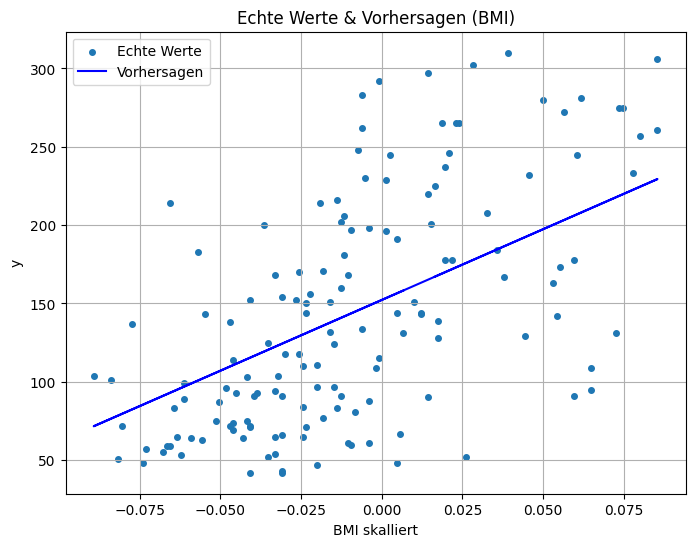

0.0 ist der Mittelwert


In [30]:
plt.figure(figsize=(8,6))

# Scatter: echte Werte
plt.scatter(X_test["bmi"], y_test, s=16, label="Echte Werte")  # s=16 ~ size 1.6

# Linie: Vorhersagen
plt.plot(X_test["bmi"], y_pred, color='blue', linewidth=1.5, label="Vorhersagen")

plt.xlabel("BMI skalliert")
plt.ylabel("y")
plt.title("Echte Werte & Vorhersagen (BMI)")
plt.legend()
plt.grid(True)
plt.show()
print("0.0 ist der Mittelwert")

# Lesson 2